# Импортируем данные:

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import numpy as np

In [2]:
df = pd.read_csv("/content/train.csv")
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


# Построим ряд столбчатых диаграмм по переменным:

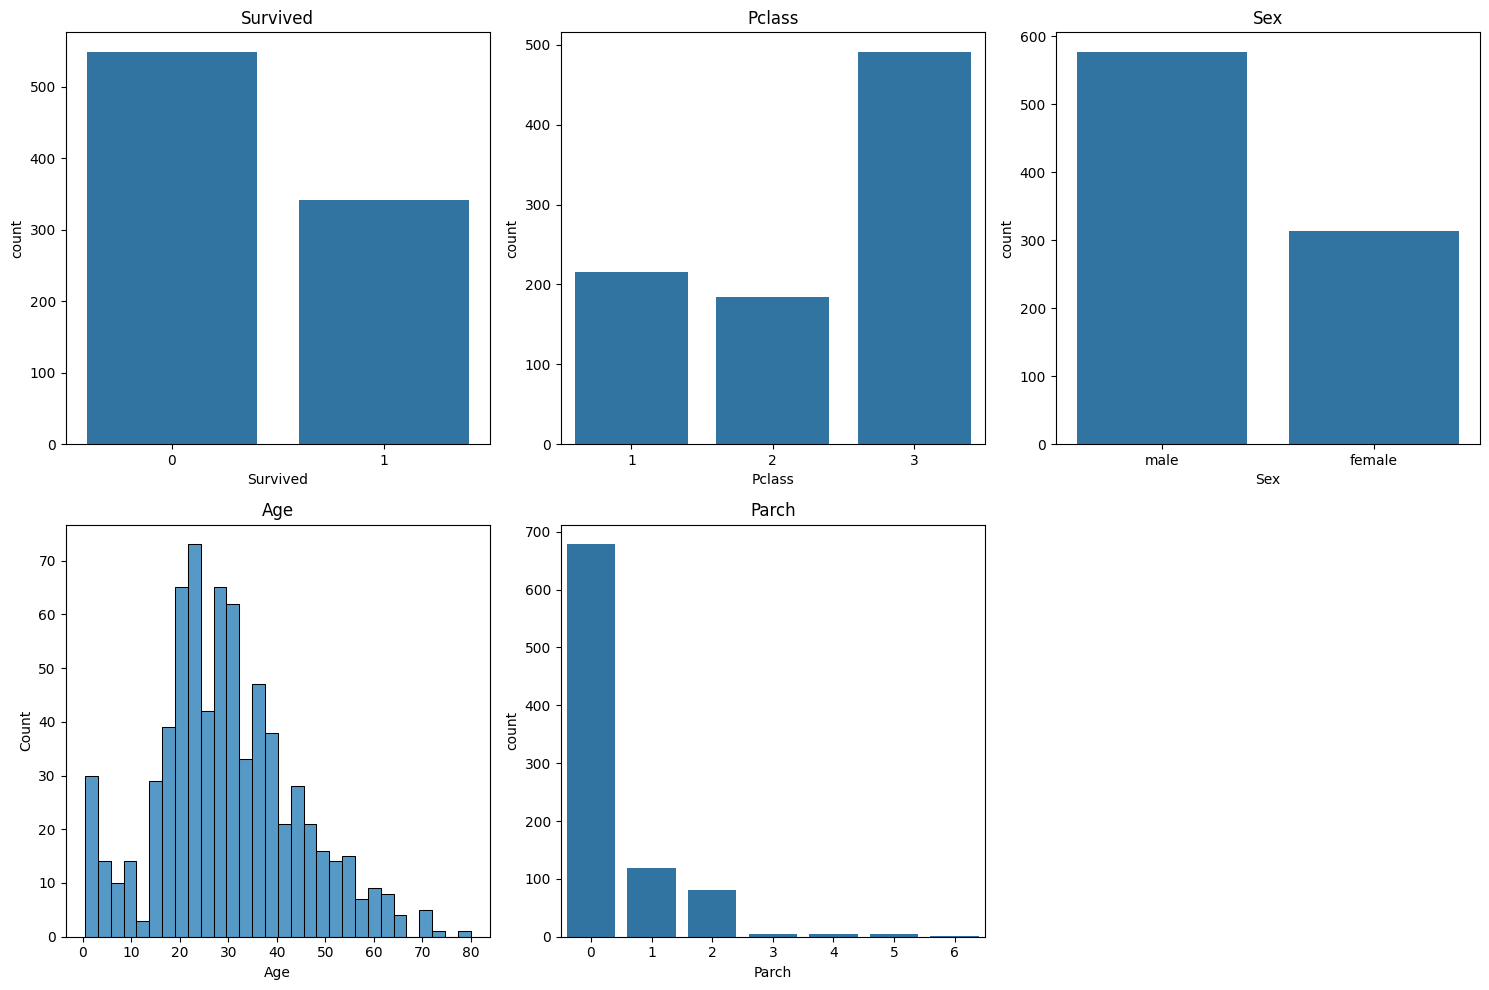

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(15,10))

sns.countplot(x="Survived", data=df, ax=axes[0,0])
axes[0,0].set_title("Survived")

sns.countplot(x="Pclass", data=df, ax=axes[0,1])
axes[0,1].set_title("Pclass")

sns.histplot(df["Age"].dropna(), bins=30, ax=axes[1,0])
axes[1,0].set_title("Age")

sns.countplot(x="Sex", data=df, ax=axes[0,2])
axes[0,2].set_title("Sex")

sns.countplot(x="Parch", data=df, ax=axes[1,1])
axes[1,1].set_title("Parch")

fig.delaxes(axes[1,2])

plt.tight_layout()
plt.show()

Интерпретируем:

```Survived```

График показывает количество погибших и выживших пассажиров; невыживших пассажиров абсолютное большинство.

```Pclass```

Распределение по классам показывает, что абсолютное большинство пассажиров плыли третьим классом.

```Age```

Согласно гистограмме, основная часть пассажиров находилась в возрастном диапазоне от 20 до 40 лет.
Дети и пожилые пассажиры тоже были, но их меньше.

```Sex```

Пассажиров-мужчин обнаружено почти в два раза больше, чем женщин.

```Parch```

Большинство пассажиров не имели на борту зарегистрированных родителей/детей. Если имели, чаще всего одного-двух, гораздо реже 3-6.

# Построим диаграмму размаха по признаку ```Age```:



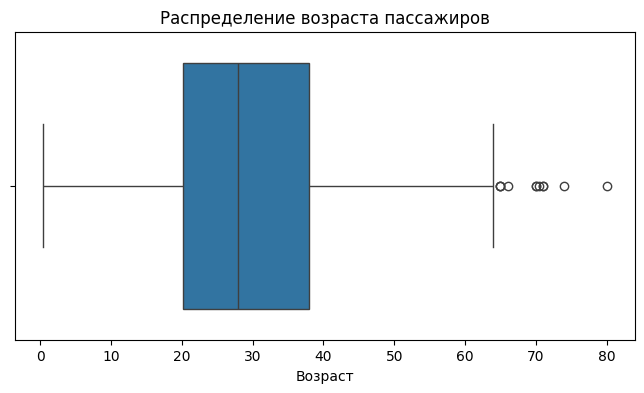

In [4]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df["Age"])

plt.title("Распределение возраста пассажиров")
plt.xlabel("Возраст")

plt.show()

Можем увидеть на графике, что медианный возраст ≈28 лет. Большая часть пассажиров (50% - межквартильный размах) имеет возраст от ~20 до ~38 лет. Выбросами считаются случаи, когда возраст выше ~64 лет. Без учета выбросов возраст пассажиров 0 < x < ~64.

# Построим круговые диаграммы, отражающие выживаемость ```Survival```:

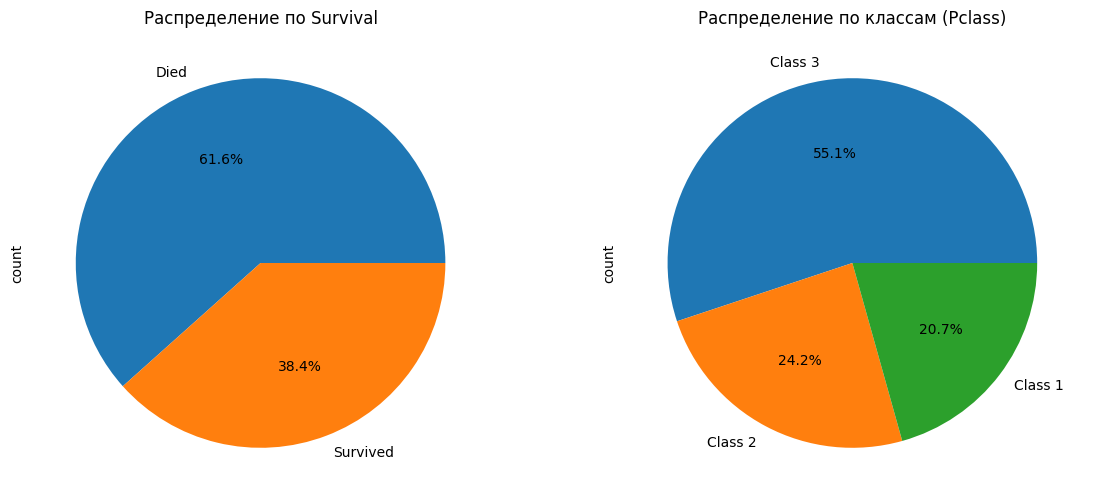

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

#Survived
axes[0].set_title("Распределение по Survival")
df['Survived'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    labels=['Died','Survived'],
    ax=axes[0])

#Pclass
df['Pclass'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    labels=['Class 3','Class 2','Class 1'],
    ax=axes[1])
axes[1].set_title('Распределение по классам (Pclass)')

plt.show()

```Survived```

Круговая диаграмма показывает долю выживших и погибших пассажиров. Погибших абсолютное большинство.

```Pclass```

Диаграмма показывает, что абсолютное большинство пассажиров располагалась в третьем классе; высшие классы были не столь многочисленны.

# Построим парный график для всех числовых переменных и сделаем выводы:

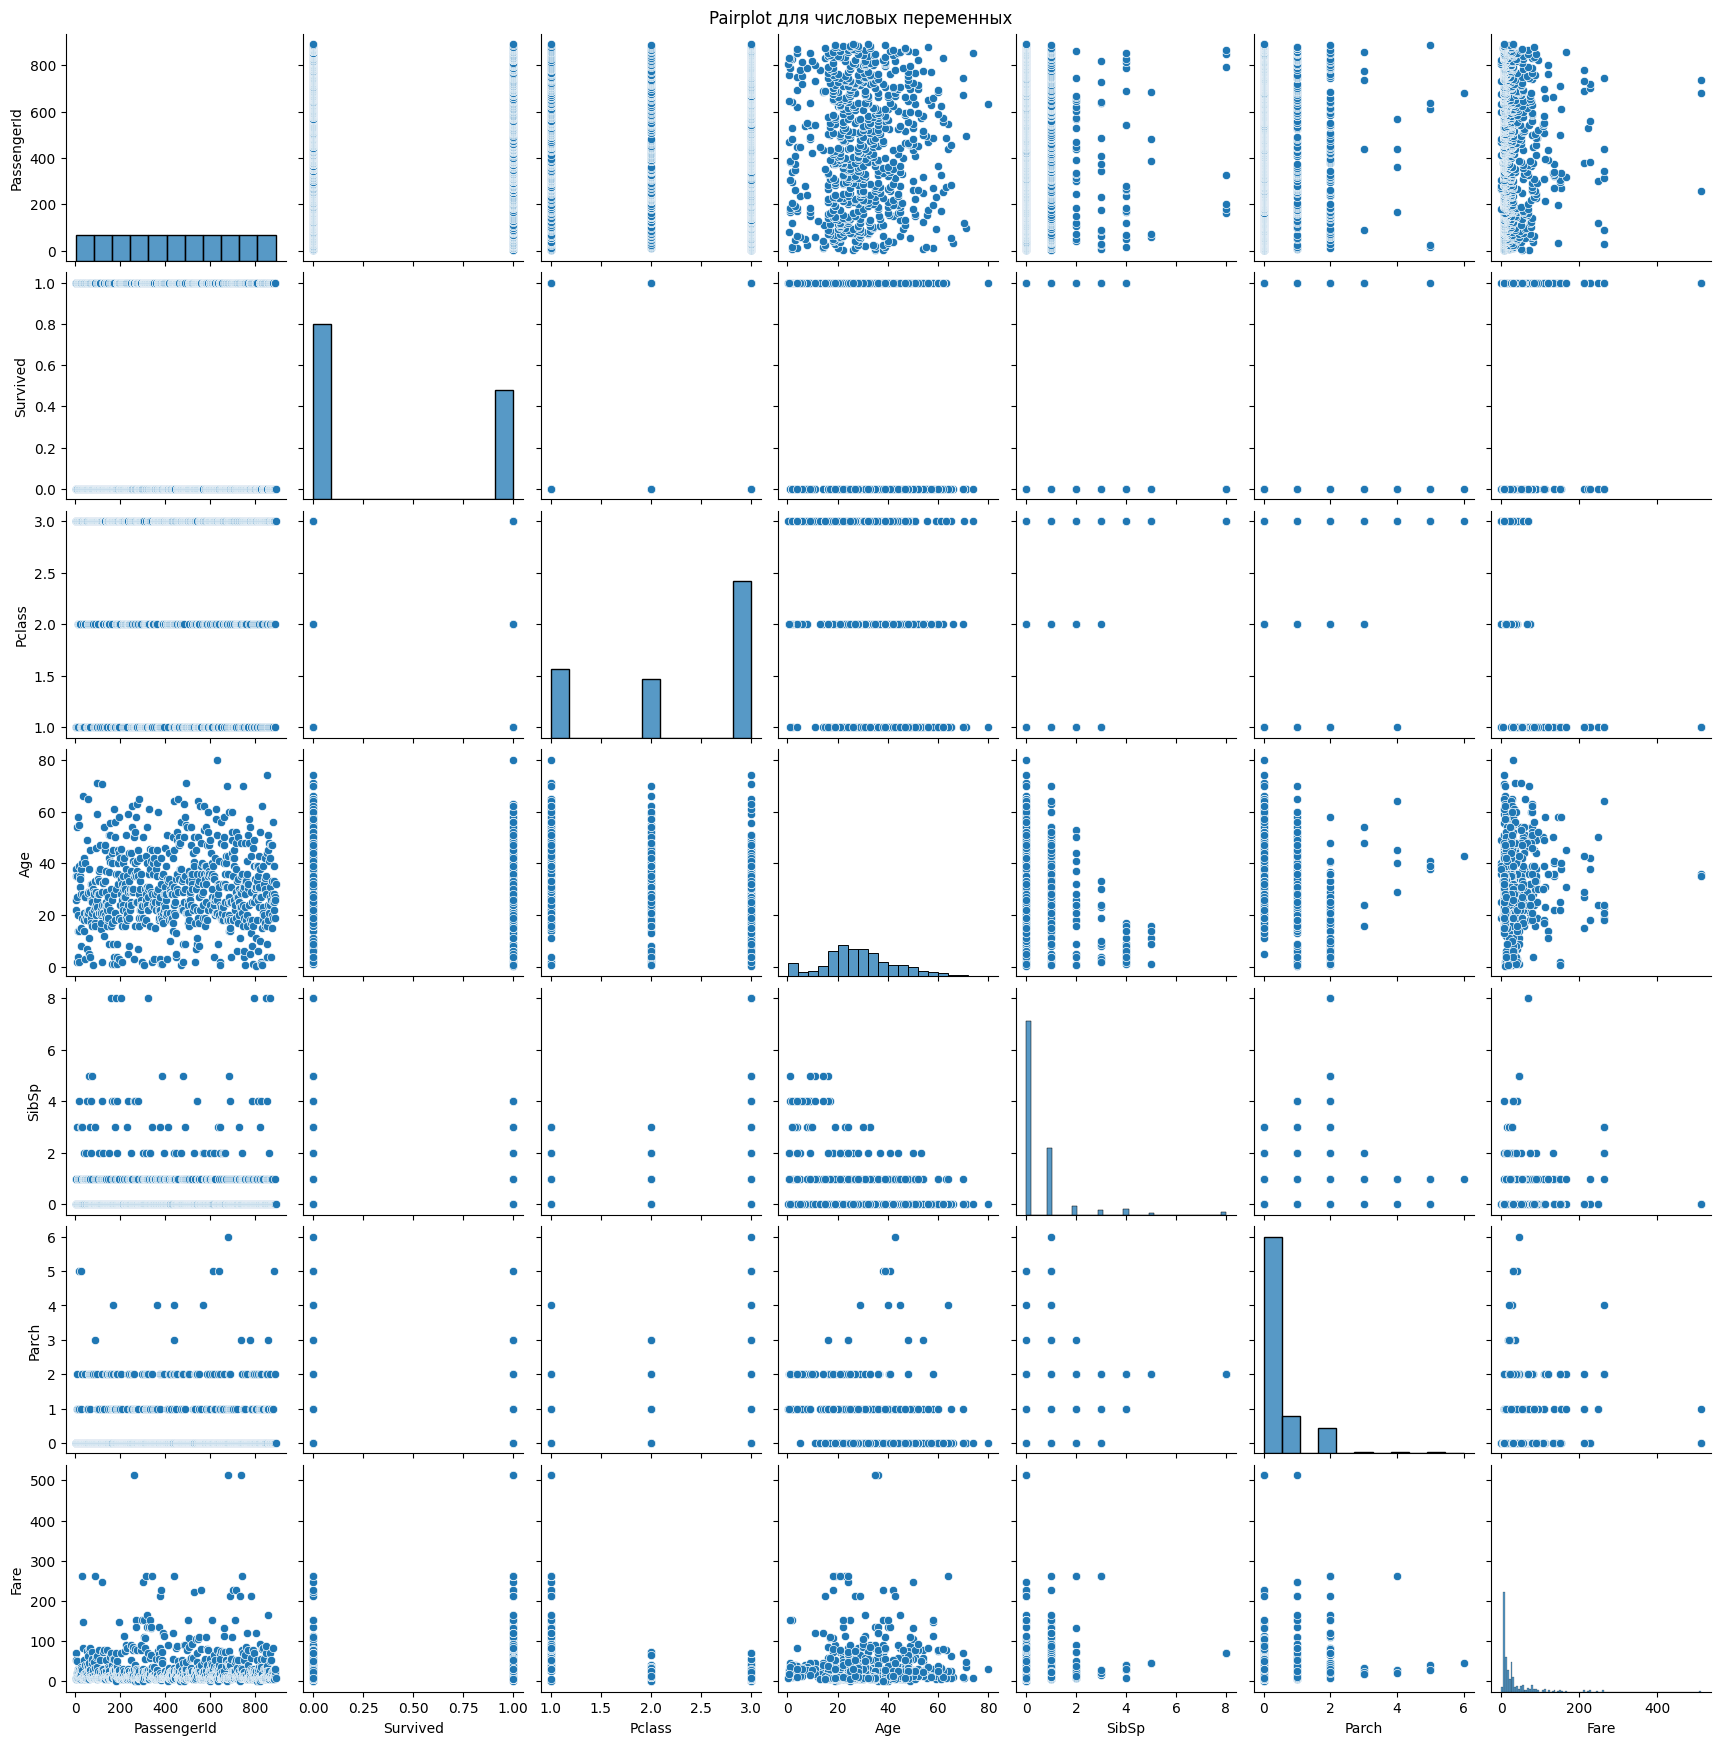

In [6]:
sns.pairplot(df.select_dtypes(include=['number']))
plt.suptitle("Pairplot для числовых переменных", y = 1)
plt.show()

График показывает, что среди числовых признаков наиболее заметная зависимость наблюдается между классом пассажира (Pclass) и стоимостью билета (Fare). Большинство пассажиров были молодыми взрослыми, а распределение стоимости билетов имеет сильную асимметрию из-за небольшого числа дорогих билетов.

# Построим violin plot распределения возраста (Age) в зависимости от пола (Sex)

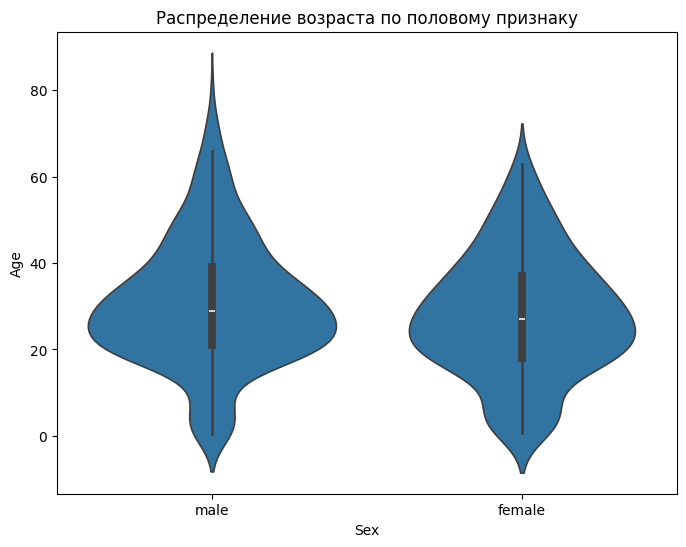

In [7]:
plt.figure(figsize=(8,6))

sns.violinplot(x='Sex', y='Age', data=df)

plt.title("Распределение возраста по половому признаку")
plt.xlabel("Sex")
plt.ylabel("Age")

plt.show()

Распределения возраста для мужчин и женщин отличаются. Среди пассажиров присутствуют как дети, так и взрослые разных возрастных групп. Распределение возраста у мужчин немного шире, что говорит о большем разнообразии возрастов. На борту было больше молодых женщин, чем мужчин. Медиана у женщин тоже чуть меньше, чем у мужчин.

# Построим тепловую карту (heatmap) корреляционной матрицы числовых признаков

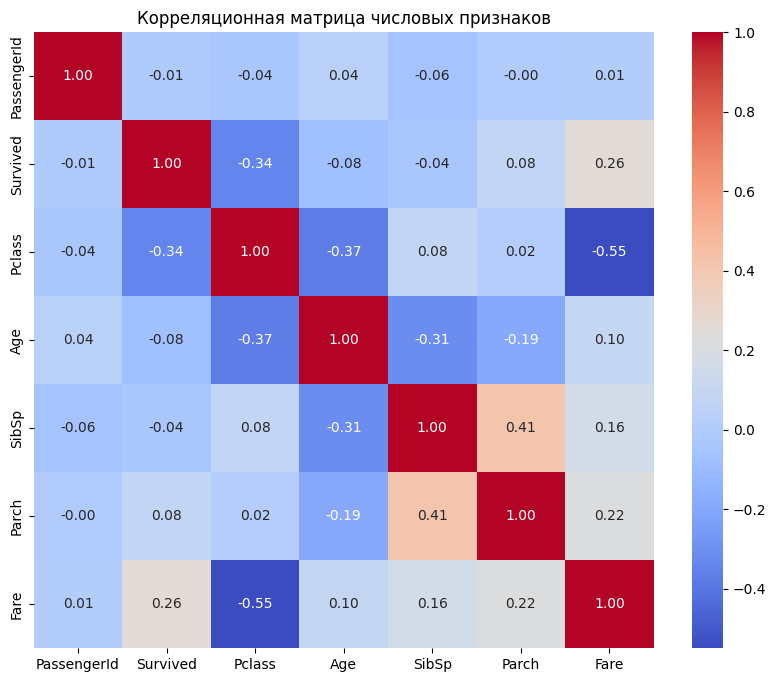

In [8]:
plt.figure(figsize=(10,8))
corr = df.select_dtypes(include=['number']).corr()
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Корреляционная матрица числовых признаков")

plt.show()

По данной матрице можно наблюдать следующие корреляции:

1. Survived

- Для признака выживаемости можно наблюдать умеренную отрицательную корреляцию с классом, что нам говорит о том, что люди из класса выше (1) выживали чуть чаще остальных.

- Как следствие, у тех, кто выжил, стоимость билета была чуть выше (умеренная корреляция). C остальными признаками корреляция почти отсутствует.

2. Pclass

- Наблюдается умеренная обратная корреляция с возрастом, что значит, люди старше чаще других выбирали класс выше (1)

- Также визуализируется средняя обратная корреляция между классом и стоимостью билета (что логично, чем выше класс, тем дороже билет)

3. Age

- Наблюдается умеренная обратная корреляция между признаком возраста и сиблингами. Люди младше чаще имели на борту братьев/сестер

4. Sibsp

- Наблюдается умеренная корреляция между людьми с братьями/сестрами на борту и родителями/детьми. Можем утверждать, что нормальная доля людей путешествовала целыми семьями.

# Построим sunburst plot:

In [9]:
sunburst_df = df.groupby(['Pclass','Sex']).size().reset_index(name='count')

fig = px.sunburst(
    sunburst_df,
    path=['Pclass','Sex'],
    values='count',
    title="Распределение пассажиров по классам и полу (Sunburst Plot)'"
)

fig.show()

Диаграмма показывает структуру пассажиров по классу и полу.

Из диаграммы можно сделать следующие выводы:

1. Наибольшее количество пассажиров находилось в третьем классе
2. Мужчин в целом было больше, чем женщин - в каждом классе.